In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [7]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [9]:
df.shape

(400, 5)

In [11]:
df.drop("User ID", axis=1)

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [15]:
print("Purchased : ", df['Purchased'].value_counts())

Purchased :  Purchased
0    257
1    143
Name: count, dtype: int64


In [17]:
df['Gender'] = df['Gender'].map({0:"Male", 1:"Female"})

In [19]:
df_numeric = df.select_dtypes(["int64", "float64"])

In [21]:
corr = df_numeric.corr()

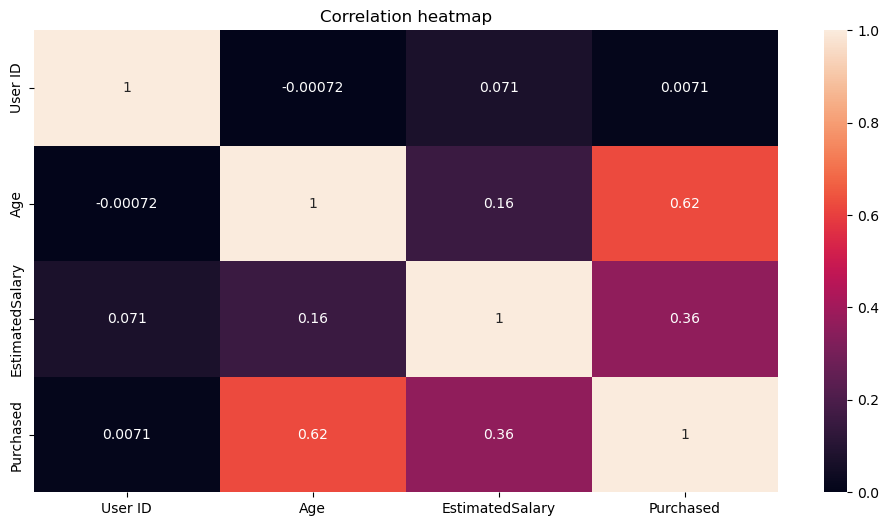

In [25]:
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation heatmap")
plt.show()

In [27]:
df.groupby('Purchased')[["Age", "EstimatedSalary"]].mean()

,Age,EstimatedSalary
Purchased,,
0,32.793774,60544.747082
1,46.391608,86272.727273


In [31]:
df['Gender_label'] = df['Gender'].map({"Male":0, "Female":1})

IndexError: index 0 is out of bounds for axis 0 with size 0

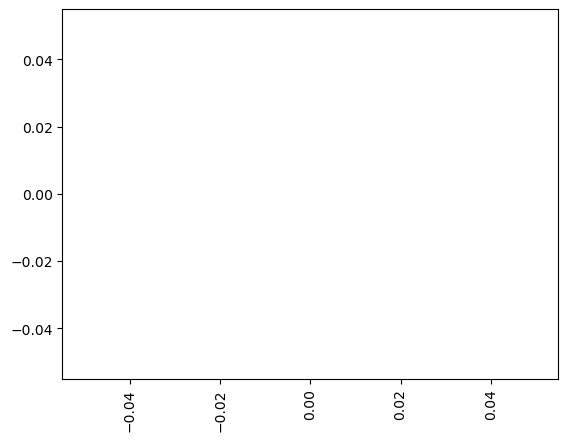

In [37]:
df['Gender_label'].value_counts().plot(kind="bar")

In [41]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=43)

sc = StandardScaler()

X = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [45]:
y_pred = model.predict(X_test)

C:\Users\kunal\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [47]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[63,  0],
       [37,  0]], dtype=int64)